In [89]:
# Modello disco SS + power law con cutoff
# Calcolo dei covering factor per tutti i blazar e tutti i 4 scenari

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1. Costanti fisiche
# =========================
c = 2.99792458e10
G = 6.67430e-8
h = 6.62607015e-27
kB = 1.380649e-16
sigma = 5.670374419e-5
Msun = 1.98847e33

# =========================
# 2. Parametri globali
# =========================
eta = 0.083
Nr = 2000
Nnu = 600
nu_min = 1e13
nu_max = 1e18

file_linee = "Tab_completa_revisione.csv"
file_transizioni = "dati.asc"

SCENARI = [
    {"scenario": "MBH_5e8_lambda_0.01", "MBH_solar": 5e8, "lambda_edd": 0.01},
    {"scenario": "MBH_5e8_lambda_0.1",  "MBH_solar": 5e8, "lambda_edd": 0.1},
    {"scenario": "MBH_1e9_lambda_0.01", "MBH_solar": 1e9, "lambda_edd": 0.01},
    {"scenario": "MBH_1e9_lambda_0.1",  "MBH_solar": 1e9, "lambda_edd": 0.1},
]



In [90]:
# =========================
# 3. Parametri della power law
# =========================
alpha_pow = 1.5
nu_ref_pow = 1e15
frac_ref_pow = 0.1
nu_cut_pow = 3e17

# %%
# =========================
# 4. Funzioni utili
# =========================
def trova_colonna(df, possibili_nomi, obbligatoria=True):
    for nome in possibili_nomi:
        if nome in df.columns:
            return nome
    if obbligatoria:
        raise ValueError(f"Non trovo nessuna di queste colonne: {possibili_nomi}")
    return None


def costruisci_spettro_disco(
    MBH_solar,
    lambda_edd,
    eta=0.083,
    Nr=2000,
    Nnu=600,
    nu_min=1e13,
    nu_max=1e18
):
    """
    Costruisce lo spettro del disco SS.
    Restituisce nu, Lnu_ss, nuLnu_ss, info.
    """
    MBH = MBH_solar * Msun
    Ledd = 1.3e38 * MBH_solar
    Ldisk = lambda_edd * Ledd
    Mdot = Ldisk / (eta * c**2)

    Rs = 2 * G * MBH / c**2
    Rin = 3 * Rs
    Rout = 3000 * Rs
    R = np.logspace(np.log10(Rin), np.log10(Rout), Nr)

    f = 1.0 - np.sqrt(Rin / R)
    f = np.clip(f, 0.0, None)

    T = ((3 * G * MBH * Mdot) / (8 * np.pi * sigma * R**3) * f) ** 0.25

    nu = np.logspace(np.log10(nu_min), np.log10(nu_max), Nnu)

    Bnu = np.zeros((Nnu, Nr))
    for j in range(Nr):
        if T[j] <= 0:
            continue
        x = h * nu / (kB * T[j])
        x = np.clip(x, 1e-12, 700.0)
        Bnu[:, j] = (2 * h * nu**3 / c**2) / (np.exp(x) - 1.0)

    integrand = R[None, :] * Bnu
    I_nu = np.trapezoid(integrand, R, axis=1)

    Lnu_ss = 4 * np.pi**2 * I_nu
    nuLnu_ss = nu * Lnu_ss

    info = {
        "MBH_solar": MBH_solar,
        "Ledd": Ledd,
        "Ldisk": Ldisk,
        "Mdot": Mdot,
        "Rs": Rs,
        "Rin": Rin,
        "Rout": Rout
    }

    return nu, Lnu_ss, nuLnu_ss, info

In [ ]:
def aggiungi_powerlaw_con_cutoff(
    nu,
    Lnu_ss,
    alpha=2,#pendenza della power law
    nu_ref=1e14,#punto di riferimento per la normalizzazione
    frac_ref=0.1,#quanto vale la power law rispetto al disco al punto di riferimento,fisicamente è plausibile che la potenza della corona sia una frazione del disco, e questa frazione può essere dell'ordine del 10% o meno
    nu_cut=5e16#frequenza di cutoffalpha_pow = 2.0
nu_ref_pow = 1e15
frac_ref_pow = 0.1
nu_cut_pow = 3e17
):
    """
    Costruisce una power law del tipo:
    Lnu_pow = A (nu/nu_ref)^(-alpha) exp(-nu/nu_cut)

    con normalizzazione fissata da:
    Lnu_pow(nu_ref) = frac_ref * Lnu_ss(nu_ref)
    """
    Lnu_ref = np.interp(nu_ref, nu, Lnu_ss)#interpolazione per trovare Lnu del disco al punto di riferimento
    A = frac_ref * Lnu_ref#calcolo della normalizzazione della power law

    Lnu_pow = A * (nu / nu_ref) ** (-alpha) * np.exp(-nu / nu_cut)
    Lnu_tot = Lnu_ss + Lnu_pow

    return Lnu_pow, Lnu_tot


In [92]:
def costruisci_spettro_totale(
    MBH_solar,
    lambda_edd,
    eta=0.083,
    Nr=2000,
    Nnu=600,
    nu_min=1e13,
    nu_max=1e17,
    alpha_pow=2,
    nu_ref_pow=1e14,
    frac_ref_pow=0.1,
    nu_cut_pow=5e16
):
    """
    Costruisce lo spettro totale = disco SS + power law con cutoff.
    """
    nu, Lnu_ss, nuLnu_ss, info = costruisci_spettro_disco(
        MBH_solar=MBH_solar,
        lambda_edd=lambda_edd,
        eta=eta,
        Nr=Nr,
        Nnu=Nnu,
        nu_min=nu_min,
        nu_max=nu_max
    )

    Lnu_pow, Lnu_tot = aggiungi_powerlaw_con_cutoff(
        nu=nu,
        Lnu_ss=Lnu_ss,
        alpha=alpha_pow,
        nu_ref=nu_ref_pow,
        frac_ref=frac_ref_pow,
        nu_cut=nu_cut_pow
    )

    nuLnu_tot = nu * Lnu_tot

    info["alpha_pow"] = alpha_pow
    info["nu_ref_pow"] = nu_ref_pow
    info["frac_ref_pow"] = frac_ref_pow
    info["nu_cut_pow"] = nu_cut_pow

    return nu, Lnu_ss, Lnu_pow, Lnu_tot, nuLnu_tot, info


In [93]:
def leggi_transizioni(file_transizioni):
    """
    Legge dati.asc con 3 colonne:
    nome_transizione   E_ion   nu_ion
    """
    names, Eion, nu_ion_list = np.genfromtxt(
        file_transizioni,
        dtype=("U50", float, float),
        unpack=True
    )

    return pd.DataFrame({
        "line_name": names,
        "E_ion": Eion,
        "nu_ion": nu_ion_list
    })


def calcola_lion_per_transizioni(nu, Lnu, df_trans, nu_max=1e18):
    """
    Calcola:
    L_ion = integral_{nu_ion}^{nu_max} Lnu dnu
    per ogni transizione.
    """
    risultati = []

    for _, row in df_trans.iterrows():
        line_name = row["line_name"]
        E_ion = row["E_ion"]
        nu_ion = row["nu_ion"]

        if nu_ion >= nu_max:
            L_ion = 0.0
        else:
            mask = (nu >= nu_ion) & (nu <= nu_max)
            if np.sum(mask) < 2:
                L_ion = 0.0
            else:
                L_ion = np.trapezoid(Lnu[mask], nu[mask])

        risultati.append({
            "line_name": line_name,
            "E_ion": E_ion,
            "nu_ion": nu_ion,
            "L_ion": L_ion
        })

    return pd.DataFrame(risultati)


def estrai_linee_osservate(row, norm_columns):
    """
    Estrae le linee osservate positive da una riga del dataframe.
    """
    risultati = []

    for col in norm_columns:
        valore = row[col]
        if pd.isna(valore) or valore <= 0:
            continue

        line_name = col.replace("_norm", "")
        L_line = valore * 1e42

        risultati.append({
            "line_name": line_name,
            "norm_value": valore,
            "L_line": L_line
        })

    return pd.DataFrame(risultati)


In [94]:
def fai_grafico_spettro_totale(nu, Lnu_ss, Lnu_pow, Lnu_tot, df_lion, nome_blazar, scenario_name):
    plt.figure(figsize=(8, 6))

    plt.loglog(nu, Lnu_ss, color="black", lw=2, label="Disco SS")
    plt.loglog(nu, Lnu_pow, color="red", lw=2, ls="--", label="Power law + cutoff")
    plt.loglog(nu, Lnu_tot, color="blue", lw=2, label="Totale")

    cmap = plt.get_cmap("tab10")
    colors = [cmap(i % cmap.N) for i in range(len(df_lion))]

    for (_, row), col in zip(df_lion.iterrows(), colors):
        plt.axvline(row["nu_ion"], color=col, lw=1.2, alpha=0.7)

    plt.xlabel("nu [Hz]")
    plt.ylabel("Lnu [erg s^-1 Hz^-1]")
    plt.title(f"Spettro totale - {nome_blazar} - {scenario_name}")
    plt.xlim(nu.min(), nu.max())
    plt.ylim(1e17, 1e31)
    plt.legend()
    plt.grid(True, which="both", alpha=0.25)
    plt.tight_layout()
    plt.show()


def analizza_blazar_powerlaw(
    row,
    df_trans,
    norm_columns,
    mostra_grafico=True,
    verbose=True,
    alpha_pow=2,
    nu_ref_pow=1e14,
    frac_ref_pow=0.1,
    nu_cut_pow=5e16
):
    nome_blazar = row["label"]
    MBH_solar = row["MBH_solar"]
    lambda_edd = row["lambda_edd"]
    scenario_name = row["scenario"]
    redshift = row["redshift"] if "redshift" in row.index else np.nan

    if verbose:
        print("=" * 80)
        print(f"Scenario = {scenario_name}")
        print(f"Blazar: {nome_blazar}")
        print(f"redshift = {redshift}")
        print(f"MBH = {MBH_solar:.3e} Msun")
        print(f"lambda_edd = {lambda_edd:.3f}")
        print(f"alpha_pow = {alpha_pow}")
        print(f"frac_ref_pow = {frac_ref_pow}")
        print(f"nu_ref_pow = {nu_ref_pow:.3e} Hz")
        print(f"nu_cut_pow = {nu_cut_pow:.3e} Hz")

    nu, Lnu_ss, Lnu_pow, Lnu_tot, nuLnu_tot, info = costruisci_spettro_totale(
        MBH_solar=MBH_solar,
        lambda_edd=lambda_edd,
        eta=eta,
        Nr=Nr,
        Nnu=Nnu,
        nu_min=nu_min,
        nu_max=nu_max,
        alpha_pow=alpha_pow,
        nu_ref_pow=nu_ref_pow,
        frac_ref_pow=frac_ref_pow,
        nu_cut_pow=nu_cut_pow
    )

    if verbose:
        print(f"Ledd  = {info['Ledd']:.3e} erg/s")
        print(f"Ldisk = {info['Ldisk']:.3e} erg/s")
        print(f"Mdot  = {info['Mdot']:.3e} g/s")

    # uso lo spettro totale per calcolare L_ion
    df_lion = calcola_lion_per_transizioni(nu, Lnu_tot, df_trans, nu_max=nu_max)

    df_linee = estrai_linee_osservate(row, norm_columns)


    df_conf = df_linee.merge(df_lion, on="line_name", how="left")
    df_conf["covering_factor"] = df_conf["L_line"] / df_conf["L_ion"]
    df_conf.loc[
        (df_conf["L_ion"].isna()) | (df_conf["L_ion"] <= 0),
        "covering_factor"
    ] = np.nan

    if verbose:
        print("\nConfronto finale:")
        display(df_conf[["line_name", "L_line", "L_ion", "covering_factor"]])

    if mostra_grafico:
        fai_grafico_spettro_totale(
            nu, Lnu_ss, Lnu_pow, Lnu_tot, df_lion,
            nome_blazar, scenario_name
        )

    return df_conf

In [95]:
# =========================
# 5. Lettura dei file
# =========================
df_tab = pd.read_csv(file_linee)
df_trans = leggi_transizioni(file_transizioni)

col_name_tab = trova_colonna(df_tab, ["label", "file_name", "name", "nome", "blazar"])
norm_columns = [col for col in df_tab.columns if col.endswith("_norm")]

df_all = df_tab.rename(columns={col_name_tab: "label"}).copy()

#print("Prime righe della tabella input:")
#display(df_all.head())

#print("Transizioni:")
#display(df_trans)


Scenario = MBH_5e8_lambda_0.01
Blazar: J1745.6
redshift = 0.078
MBH = 5.000e+08 Msun
lambda_edd = 0.010
alpha_pow = 1.5
frac_ref_pow = 0.1
nu_ref_pow = 1.000e+15 Hz
nu_cut_pow = 3.000e+17 Hz
Ledd  = 6.500e+46 erg/s
Ldisk = 6.500e+44 erg/s
Mdot  = 8.714e+24 g/s

Confronto finale:


,line_name,L_line,L_ion,covering_factor
0,Ha,3.631777e+42,6.022787e+44,0.006030
1,Hb,1.103068e+42,5.425865e+44,0.002033


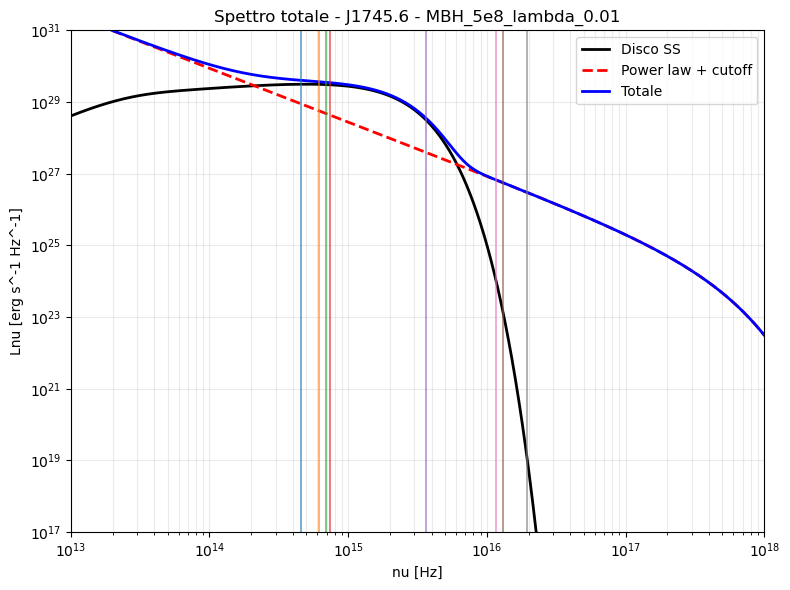

In [96]:
# =========================
# 6. Test di un singolo blazar in un singolo scenario
# =========================
scenario_test = SCENARI[0]

df_all_test = df_all.copy()
df_all_test["MBH_solar"] = scenario_test["MBH_solar"]
df_all_test["lambda_edd"] = scenario_test["lambda_edd"]
df_all_test["scenario"] = scenario_test["scenario"]

indice_blazar = 0
row_test = df_all_test.iloc[indice_blazar]

df_test = analizza_blazar_powerlaw(
    row=row_test,
    df_trans=df_trans,
    norm_columns=norm_columns,
    mostra_grafico=True,
    verbose=True,
    alpha_pow=alpha_pow,
    nu_ref_pow=nu_ref_pow,
    frac_ref_pow=frac_ref_pow,
    nu_cut_pow=nu_cut_pow
)
